<a href="https://colab.research.google.com/github/Ishank2301/CodeAlpha-DiseasePredictionfromMedicalData/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Important Libraries:

In [83]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Import and load dataset:

In [84]:
df = pd.read_csv("heart.csv")


# Performing EDA:

In [85]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [87]:
df.shape

(1025, 14)

In [88]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**As we can see there is no NULL Data so we are not required to perform any operations as no data is missing**

In [89]:
print(df.duplicated().sum())

723


**Ok so we do not have NULL Data but we have Lots of duplicate data so let's drop these duplicates**

In [90]:
df = df.drop_duplicates()

# Divide Data into x & y:

In [91]:
# X and y represents dependant and independant variable or features respectively:


X = df.drop("target", axis=1)

y = df["target"]

# Observing the data distribution:

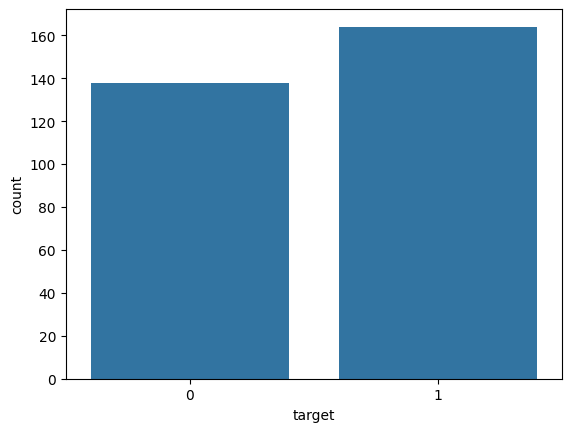

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="target",
    data=df
)

plt.show()

**Ok so we have less not detected(0) than detected(1)**

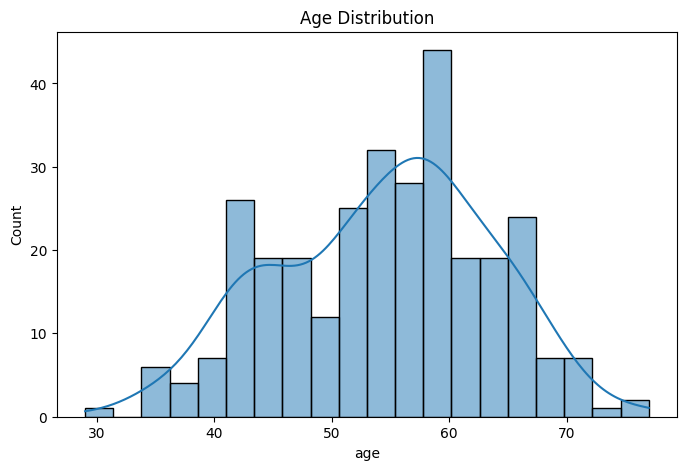

In [93]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

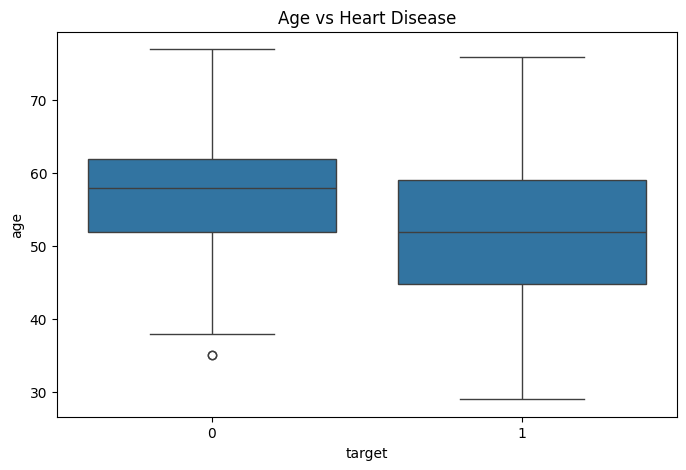

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="age"
)

plt.title(
    "Age vs Heart Disease"
)

plt.show()

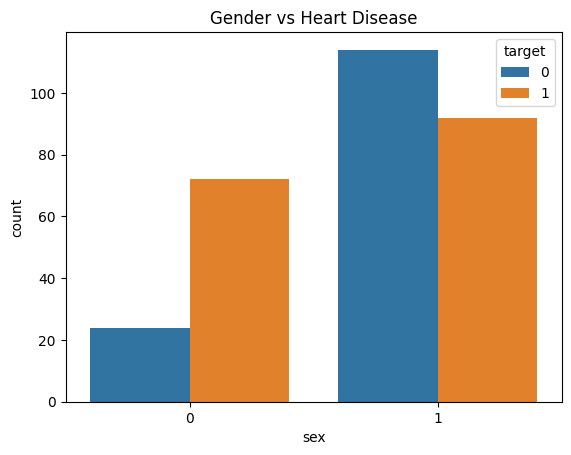

In [95]:
sns.countplot(
    data=df,
    x="sex",
    hue="target"
)

plt.title(
    "Gender vs Heart Disease"
)

plt.show()



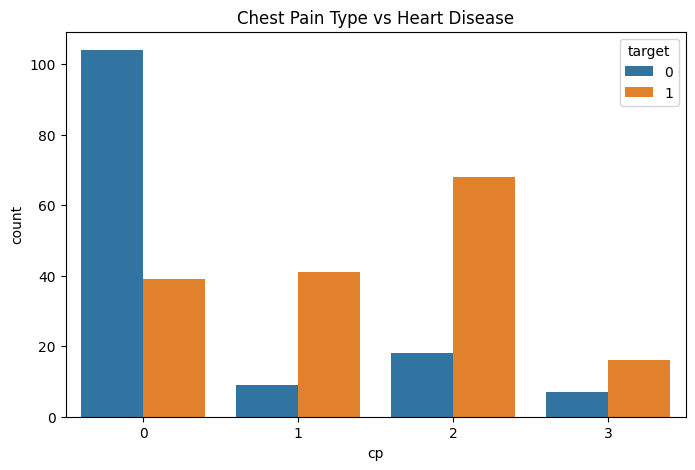

In [96]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="cp",
    hue="target"
)

plt.title(
    "Chest Pain Type vs Heart Disease"
)

plt.show()

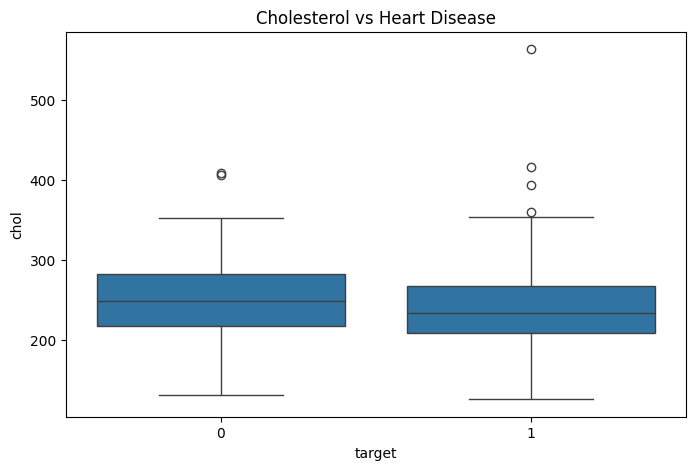

In [97]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="chol"
)

plt.title(
    "Cholesterol vs Heart Disease"
)

plt.show()

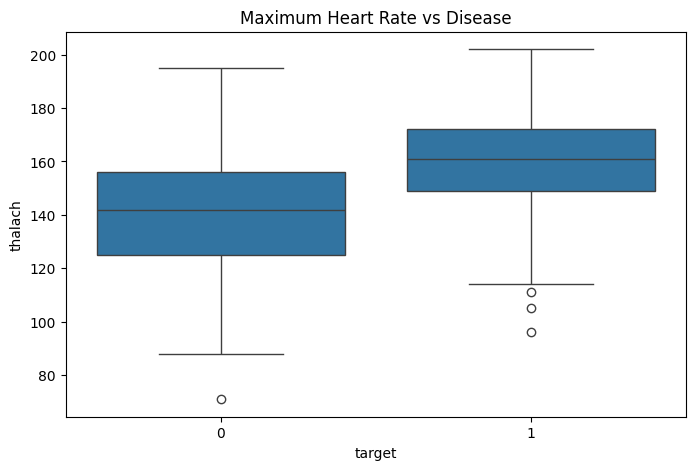

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="target",
    y="thalach"
)

plt.title(
    "Maximum Heart Rate vs Disease"
)

plt.show()

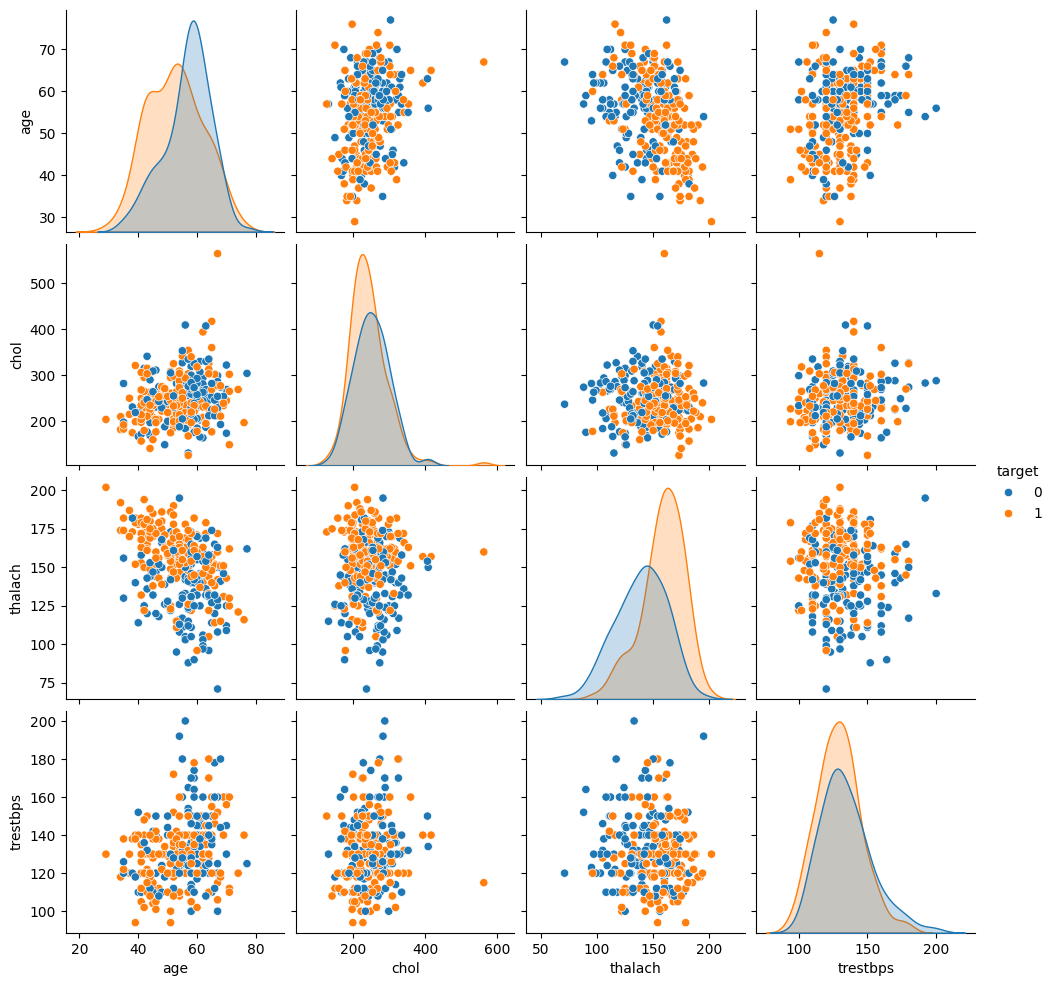

In [99]:
sns.pairplot(
    df,
    hue="target",
    vars=[
        "age",
        "chol",
        "thalach",
        "trestbps"
    ]
)

plt.show()

# Correlation Analysis:

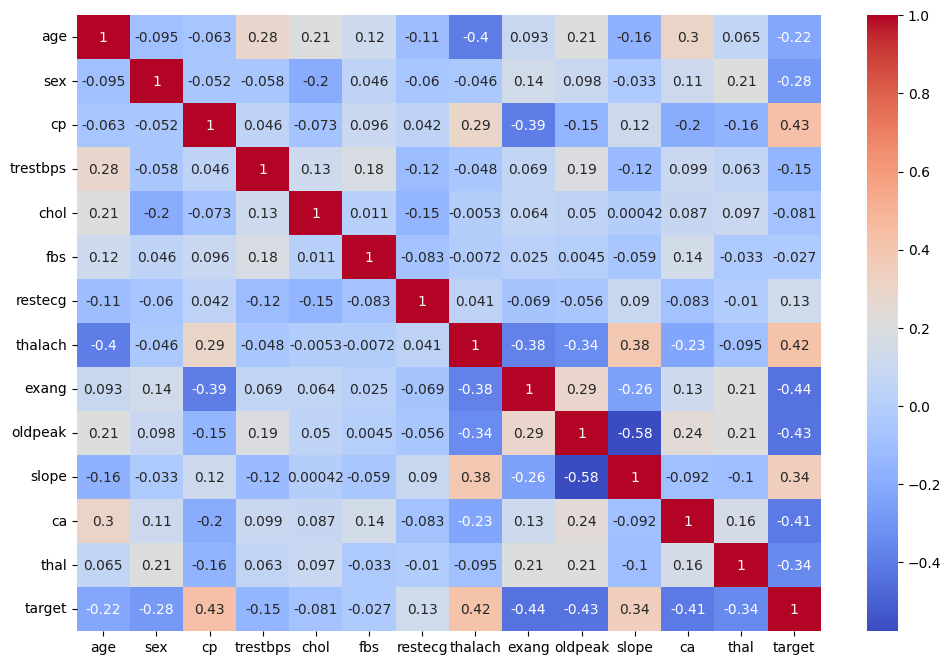

In [100]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Scaling the data:

In [101]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

# Split the data:

In [102]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create a pipeline to fit ML algorithums:

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42
    )
}

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred
        ),
        "Recall": recall_score(
            y_test,
            y_pred
        ),
        "F1": f1_score(
            y_test,
            y_pred
        )
    })

# Compare Results of different models:

In [105]:
import pandas as pd

results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,SVM,0.770492,0.771429,0.818182,0.794118
2,Random Forest,0.754098,0.764706,0.787879,0.776119
3,XGBoost,0.721311,0.735294,0.757576,0.746269


 # Visualizing Result:

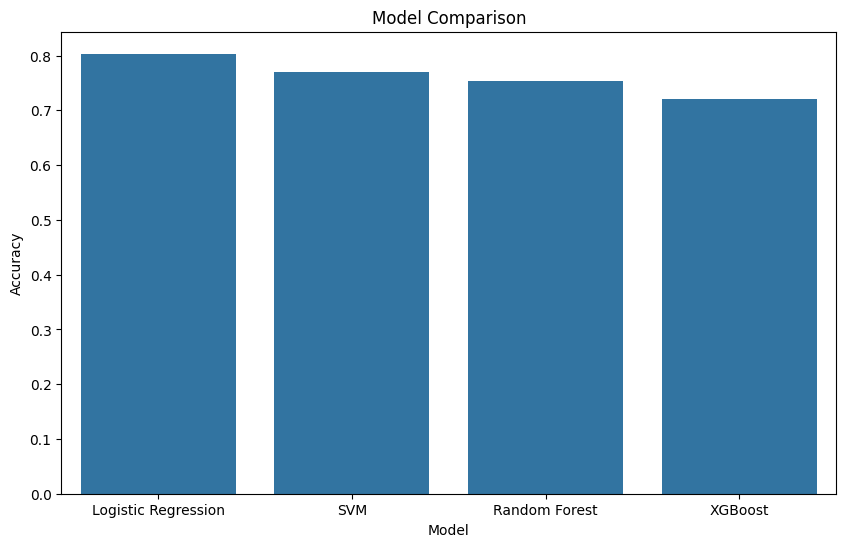

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Comparison"
)

plt.show()

**As we can see the best models are LogisticRegression and SVM  and they have the highest accuracy**

# Feature Importance:

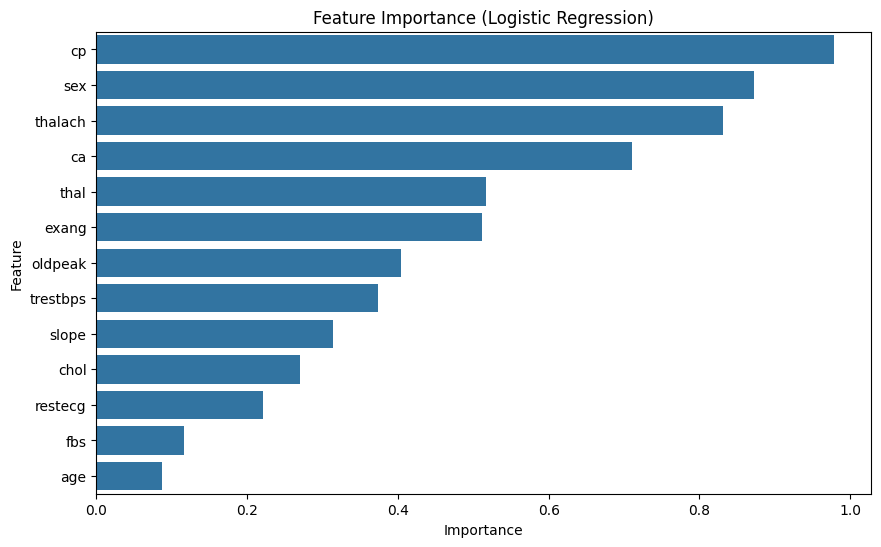

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lr_model = models["Logistic Regression"]

lr_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": df.drop("target", axis=1).columns,
    "Importance": np.abs(lr_model.coef_[0])
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance (Logistic Regression)"
)

plt.show()

In [115]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[
    best_model_name
]

print(
    f"Best Model: {best_model_name}"
)

Best Model: Logistic Regression


# Saving the Best model:

In [118]:
import os

os.makedirs("models", exist_ok=True)
import joblib

joblib.dump(
    best_model,
    "models/best_model.pkl"
)

joblib.dump(
    sc,
    "models/scaler.pkl"
)

['models/scaler.pkl']